<div style='background: linear-gradient(135deg, #667eea 0%, #b1d54e 100%); padding: 40px; border-radius: 15px; box-shadow: 0 10px 30px rgba(0,0,0,0.3);'>
    <h1 style='color: white; text-align: center; font-size: 48px; margin: 0; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>HELP ONG x VisionDataLab</h1>
    <h2 style='color: #e0e7ff; text-align: center; font-size: 28px; margin-top: 15px; font-weight: 300;'>Merge datasets</h2>
    <p style='color: white; text-align: center; font-size: 16px; margin-top: 20px; opacity: 0.9;'>TP ML 2</p>
</div>

<style>
    /* Style global */
    body {
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    }
    
    /* Headers stylés */
    h1, h2, h3, h4 {
        font-weight: 700;
    }
    
    /* Sections colorées */
    .section-header {
        background: linear-gradient(90deg, #f093fb 0%, #f5576c 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 30px 0 20px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.2);
    }
    
    .info-box {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    .warning-box {
        background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    .success-box {
        background: linear-gradient(135deg, #43e97b 0%, #38f9d7 100%);
        padding: 20px;
        border-radius: 10px;
        color: white;
        margin: 15px 0;
        box-shadow: 0 5px 15px rgba(0,0,0,0.1);
    }
    
    /* Badges */
    .badge {
        display: inline-block;
        padding: 8px 15px;
        border-radius: 20px;
        font-size: 14px;
        font-weight: 600;
        margin: 5px;
    }
    
    .badge-primary {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
    }
    
    .badge-success {
        background: linear-gradient(135deg, #43e97b 0%, #38f9d7 100%);
        color: white;
    }
    
    .badge-warning {
        background: linear-gradient(135deg, #fa709a 0%, #fee140 100%);
        color: white;
    }
    
    /* Dividers */
    .divider {
        height: 3px;
        background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
        border: none;
        margin: 30px 0;
        border-radius: 5px;
    }
</style>

# Import package and config

In [57]:
import sys
from pathlib import Path

root_path = Path.cwd().parent 
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.config import paths
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml


## Configs

In [58]:
raw_dir=paths.DATA_DIR/"raw"
raw_dir

WindowsPath('C:/Users/HP/Desktop/temp/TODO/SEMESTRE_2/ML2/projet/data/raw')

In [59]:
root=paths.ROOT_DIR
with open(root / "configs" / "variables.yaml", "r") as f:
    config = yaml.safe_load(f)
    
sources = config["sources"]
print("Sources configurées :", list(sources.keys()))

Sources configurées : ['sante_wdi', 'sante_who', 'social_poverty_mpi', 'social_literacy', 'social_poverty_2_15', 'social_schooling', 'social_undernourishment', 'securite_civil', 'securite_political']


# Main dataset

In [60]:
df_main=pd.read_csv(raw_dir/"Country-data.csv")
df_final = df_main.copy()
df_main.info()


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [61]:
df_main.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Mapping pays

In [62]:

# Création du dictionnaire de mapping pour standardiser les noms de pays entre les différentes bases 
# Sans cela probleme de mapping
country_mapping = {
    "Egypt, Arab Rep.": "Egypt",
    "Yemen, Rep.": "Yemen",
    "Venezuela, RB": "Venezuela",
    "Russian Federation": "Russia",
    "Korea, Rep.": "South Korea",
    "Iran, Islamic Rep.": "Iran",
    "Congo, Dem. Rep.": "Congo, Dem. Rep.", # Déjà correct dans df_main, mais pour WDI
    "Congo, Rep.": "Congo, Rep.",
    "Micronesia, Fed. Sts.": "Micronesia, Fed. Sts.",
    "Bahamas, The": "Bahamas",
    "Gambia, The": "Gambia",
    "Slovak Republic": "Slovak Republic",
    "Kyrgyz Republic": "Kyrgyz Republic",
    "Macedonia, FYR": "Macedonia, FYR",
    "Brunei Darussalam": "Brunei",
    "Cabo Verde": "Cape Verde",
    "Syrian Arab Republic": "Syria",
    "Turkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "Lao PDR": "Lao"
}
countries_ref = set(df_main["country"])


# Santé wdi datasets

Les indicateurs de santé sont généralement collectés annuellement, mais certains pays peuvent avoir un décalage. Nous extrayons 2014, mais pour les données très sporadiques (comme le nombre de médecins), nous vérifierons la pertinence d'une fenêtre temporelle de 2012-2016.

In [63]:
wdi_conf = sources["sante_wdi"]
df_wdi = pd.read_csv(raw_dir / wdi_conf["file"])
df_wdi["Country"] = df_wdi["Country"].replace(country_mapping)


In [64]:
df_wdi.head(2)

,economy,series,Country,Series,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023
0,ZWE,SH.DYN.MORT,Zimbabwe,"Mortality rate, under-5 (per 1,000 live births)",59.8,59.2,57.5,56.7,56.3,58.6,61.7,62.4,64.0,64.2
1,ZMB,SH.DYN.MORT,Zambia,"Mortality rate, under-5 (per 1,000 live births)",62.6,60.2,57.1,55.2,54.7,53.5,52.5,50.4,49.5,49.1


In [65]:

# Filtrage sur nos pays cibles
df_wdi_sub = df_wdi[df_wdi["Country"].isin(countries_ref)]

# Variables WDI demandées dans le YAML
wdi_vars = wdi_conf["variables"]

# Extraction et pivot pour l'année 2014
df_h14 = df_wdi_sub.pivot(index="Country", columns="Series", values="YR2014").reset_index()
df_h14.columns.name = None

# Renommage selon le YAML
df_h14 = df_h14[["Country"] + list(wdi_vars.keys())].rename(columns=wdi_vars)


In [66]:
df_h14.head(2)

,Country,life_expectancy,physicians_per_1000,hiv_prevalence,vaccination_dpt,child_mortality,tb_incidence,maternal_mortality,health_expenditure_pct_gdp
0,Afghanistan,62.260,0.304,0.1,62.0,74.6,197.0,755.0,9.528878
1,Albania,78.029,NaN,0.1,99.0,9.9,16.0,10.0,6.358841


8 colonnes exactement comme dans le YAML

## Valeurs NA

### Description

In [67]:

na_stats = df_h14.isnull().mean() * 100
print("Pourcentage de valeurs manquantes (Santé WDI - 2014 stricte) :")
print(na_stats.sort_values(ascending=False)[na_stats > 0])

Pourcentage de valeurs manquantes (Santé WDI - 2014 stricte) :
physicians_per_1000           34.545455
hiv_prevalence                18.181818
health_expenditure_pct_gdp     0.606061
dtype: float64


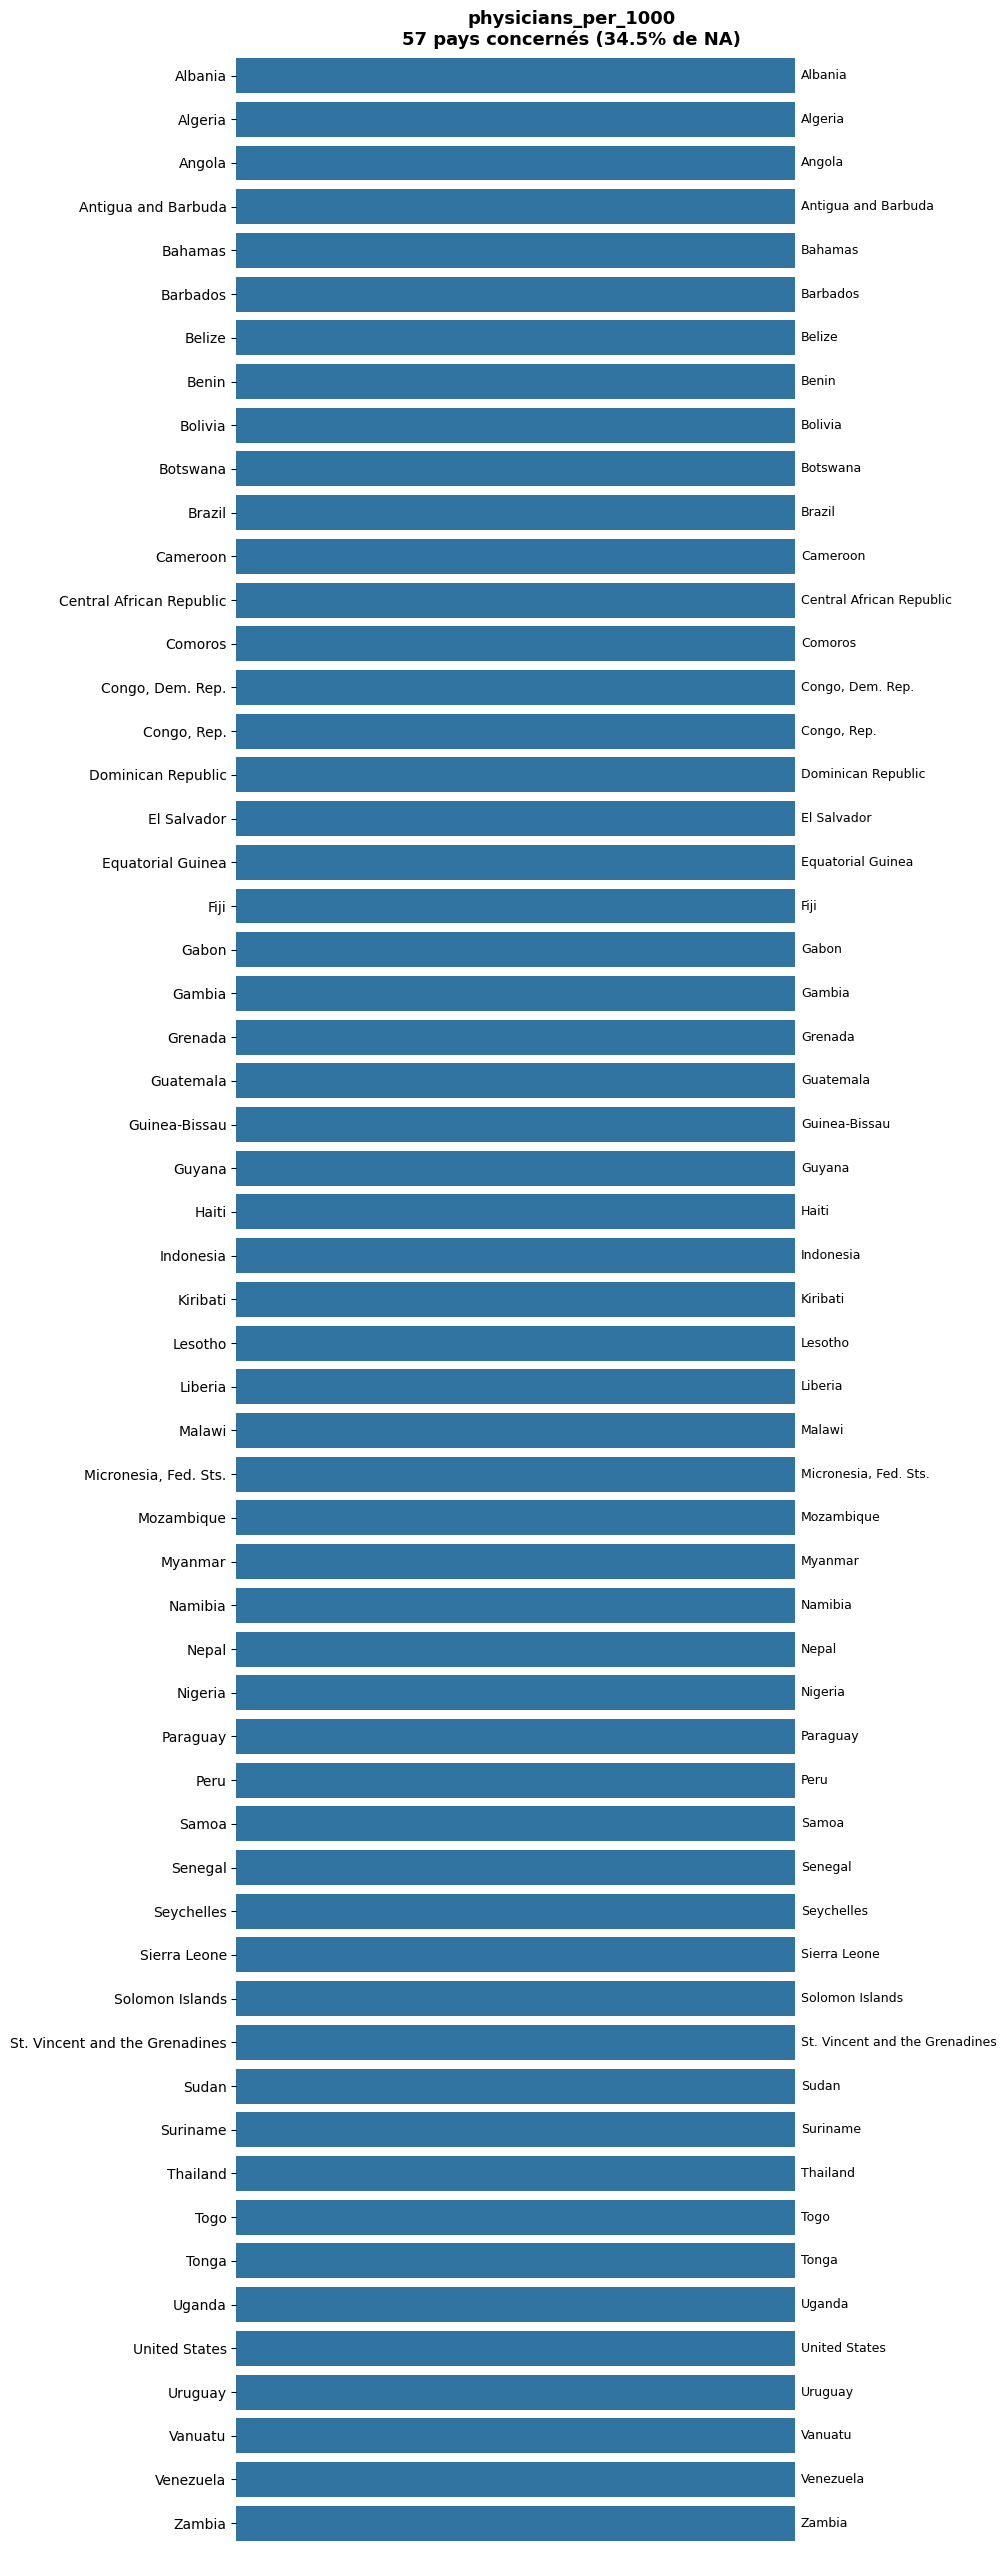

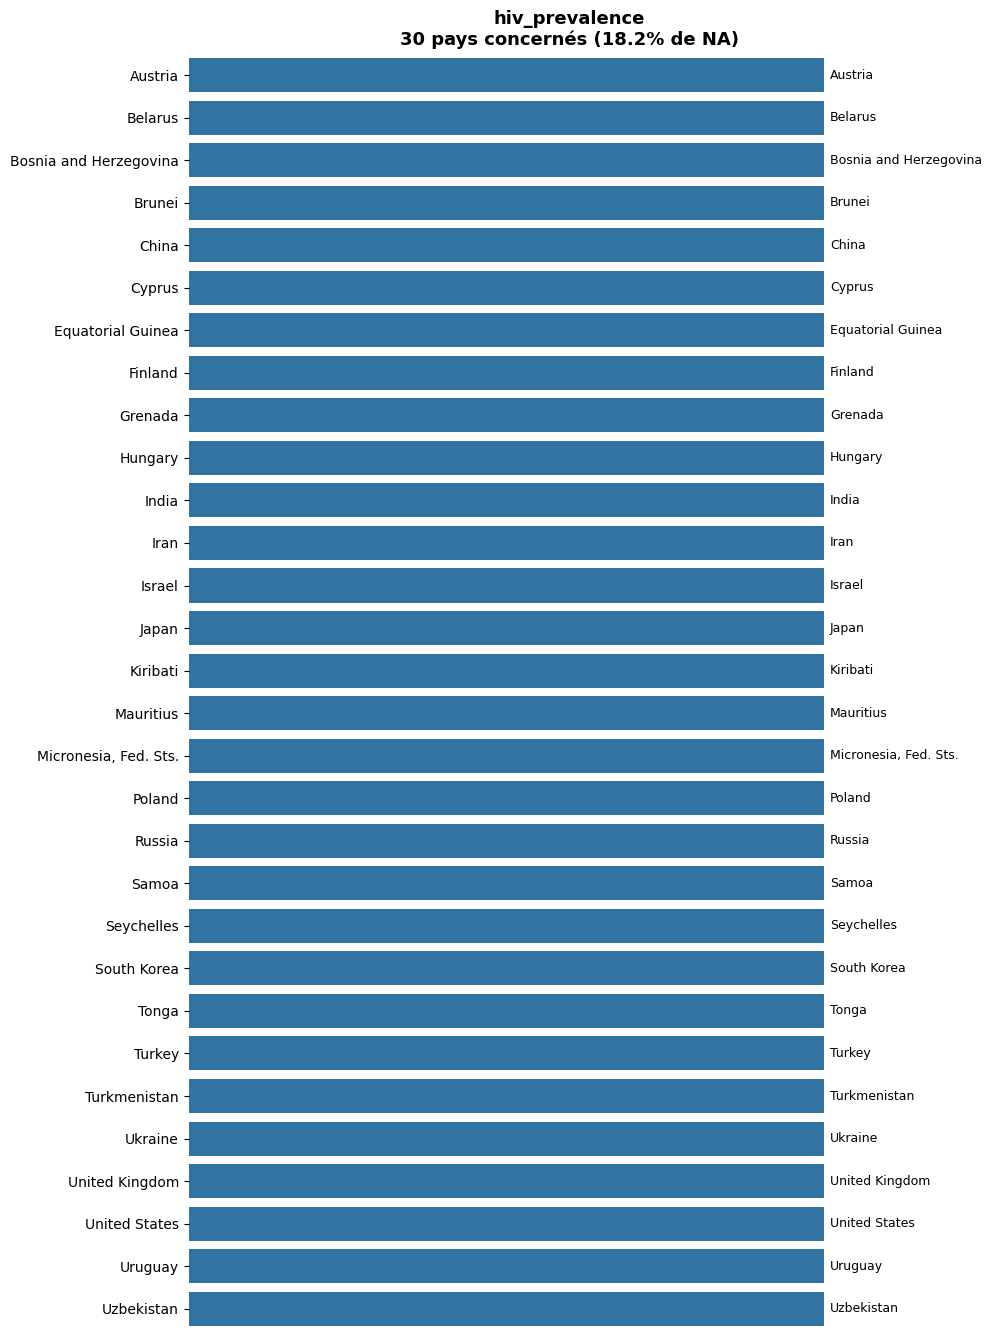

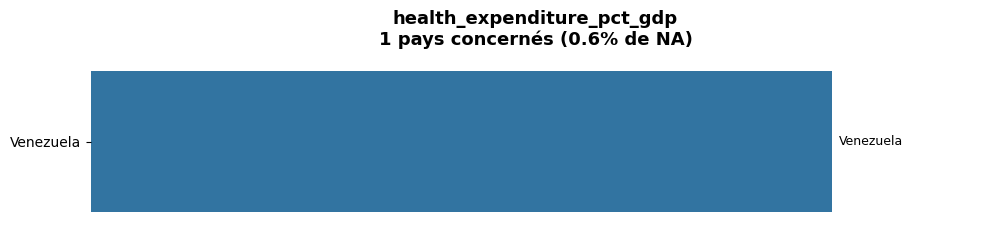

In [68]:
# Variables contenant des NA
cols_na = na_stats[na_stats > 0].sort_values(ascending=False).index

for col in cols_na:
    
    # Pays avec NA
    pays_na = df_h14[df_h14[col].isna()]["Country"]
    
    # Statistiques
    nb_na = len(pays_na)
    pct_na = na_stats[col]
    
    # Figure
    plt.figure(figsize=(10, max(2.5, nb_na * 0.45)))
    
    ax = sns.barplot(
        x=[1] * nb_na,
        y=pays_na,
        orient="h"
    )
    
    # Annotations
    for i, pays in enumerate(pays_na):
        ax.text(
            1.01,
            i,
            pays,
            va="center",
            fontsize=9
        )
    
    # Mise en forme
    plt.xlim(0, 1.2)
    plt.xticks([])
    plt.xlabel("")
    plt.ylabel("")
    
    plt.title(
        f"{col}\n"
        f"{nb_na} pays concernés ({pct_na:.1f}% de NA)",
        fontsize=13,
        weight="bold"
    )
    
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

>Le taux de médecins (physicians_per_1000) a 35% de NA en 2014. 
Vérifions si élargir la fenêtre  permet de récupérer ces pays.

### Recherche sur 2015-2017

Pourquoi 2015-2017 ? car sont proche de 2014 et le dataset demarre à 2014

#### physicians_per_1000

In [69]:
phys_series = [k for k, v in wdi_vars.items() 
               if v == "physicians_per_1000"][0]

phys_data = (
    df_wdi_sub[df_wdi_sub["Series"] == phys_series]
    [["Country", "YR2014", "YR2015", "YR2016", "YR2017"]]
    .set_index("Country")
)

# Valeur la plus proche disponible
phys_data["best_val"] = (
    phys_data
    .bfill(axis=1)
    .ffill(axis=1)["YR2014"]
)

# Sauvegarde avant/après
before_na = df_h14["physicians_per_1000"].isna()

df_h14["physicians_per_1000"] = (
    df_h14["Country"]
    .map(phys_data["best_val"])
)

after_na = df_h14["physicians_per_1000"].isna()

print("NA avant :", before_na.sum())
print("NA après :", after_na.sum())

# Pays récupérés
recovered_countries = df_h14.loc[
    before_na & ~after_na,
    "Country"
]

print("\nPays récupérés :")
print(recovered_countries.tolist())


NA avant : 57
NA après : 12

Pays récupérés :
['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Bahamas', 'Barbados', 'Belize', 'Benin', 'Bolivia', 'Botswana', 'Brazil', 'Central African Republic', 'Comoros', 'Congo, Rep.', 'El Salvador', 'Equatorial Guinea', 'Fiji', 'Gabon', 'Gambia', 'Grenada', 'Guatemala', 'Guinea-Bissau', 'Haiti', 'Indonesia', 'Liberia', 'Malawi', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Nigeria', 'Peru', 'Samoa', 'Senegal', 'Seychelles', 'Solomon Islands', 'Sudan', 'Suriname', 'Thailand', 'Togo', 'Uganda', 'Uruguay', 'Vanuatu', 'Venezuela', 'Zambia']


physicians_per_1000 est systematiquement absent 2014-2017 pour ces meme pays

#### Les autres variables

In [ ]:

vars_with_na = na_stats[na_stats > 0].index.tolist()

recovery_summary = []

for var in vars_with_na:
    
    # Nom de la série WDI correspondant
    series_code = [k for k, v in wdi_vars.items() if v == var][0]
    
    # Données temporelles
    temp_data = (
        df_wdi_sub[df_wdi_sub["Series"] == series_code]
        [["Country", "YR2014", "YR2015", "YR2016", "YR2017"]]
        .set_index("Country")
    )
    
    # Sauvegarde NA avant
    before_na = df_h14[var].isna()
    
    # Remplissage avec valeur disponible la plus proche
    temp_data["best_val"] = (
        temp_data
        .bfill(axis=1)
        .ffill(axis=1)["YR2014"]
    )
    
    # Application
    df_h14[var] = (
        df_h14["Country"]
        .map(temp_data["best_val"])
    )
    
    # Vérification après
    after_na = df_h14[var].isna()
    
    # Pays récupérés
    recovered = df_h14.loc[
        before_na & ~after_na,
        "Country"
    ].tolist()
    
    # Résumé
    recovery_summary.append({
        "Variable": var,
        "NA_avant": before_na.sum(),
        "NA_apres": after_na.sum(),
        "Pays_recuperes": len(recovered),
        "Liste_pays": recovered
    })

# Résumé global
recovery_df = pd.DataFrame(recovery_summary)

print(recovery_df[
    ["Variable", "NA_avant", "NA_apres", "Pays_recuperes"]
])



                     Variable  NA_avant  NA_apres  Pays_recuperes
0         physicians_per_1000        12        12               0
1              hiv_prevalence        30        29               1
2  health_expenditure_pct_gdp         1         1               0


In [72]:

for r in recovery_summary:
    
    var = r["Variable"]
    recovered = r["Liste_pays"]
    
    print("\n", var)
    print("Pays récupérés :", recovered)


 physicians_per_1000
Pays récupérés : []

 hiv_prevalence
Pays récupérés : ['United Kingdom']

 health_expenditure_pct_gdp
Pays récupérés : []


Ce procédé ne permet de recupérer que hiv_prevalence de United Kingdom

## Merge


In [74]:
df_final = df_final.merge(df_h14, left_on="country", right_on="Country", how="left").drop(columns=["Country"])
df_final.head(2)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,...,maternal_mortality_x,health_expenditure_pct_gdp_x,life_expectancy_y,physicians_per_1000_y,hiv_prevalence_y,vaccination_dpt_y,child_mortality_y,tb_incidence_y,maternal_mortality_y,health_expenditure_pct_gdp_y
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,...,755.0,9.528878,62.260,0.304,0.1,62.0,74.6,197.0,755.0,9.528878
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,...,10.0,6.358841,78.029,1.212,0.1,99.0,9.9,16.0,10.0,6.358841


# Santé who datasets

In [76]:
who_conf = sources["sante_who"]
df_who = pd.read_csv(raw_dir / who_conf["file"])
df_who.head(2)


,country_code,year,life_expectancy_who
0,TZA,2018,64.792958
1,DEU,2014,80.759927


La variable "life_expectancy" est deja capté dans sa version wdi,l'information existe et même dans le dataset originel elle y est donc j'estime a ce stade que on peux s'en passer.

#  Pauvreté, Nutrition, Social dataset

In [ ]:
social_keys = ["social_poverty_mpi", "social_literacy", "social_poverty_2_15", "social_schooling", "social_undernourishment"]

social_dfs = []
for key in social_keys:
    conf = sources[key]
    df_tmp = pd.read_excel(RAW / conf["file"])
    df_tmp["Country Name"] = df_tmp["Country Name"].replace(country_mapping)
    df_tmp = df_tmp[df_tmp["Country Name"].isin(countries_ref)].set_index("Country Name")
    
    # Récupération du nom de variable cible
    target_var = conf["variables"][2014]
    
    # On définit une fenêtre (ex: 2010-2020) pour chercher la valeur la plus proche de 2014
    years = [y for y in range(2010, 2021) if y in df_tmp.columns]
    filled = df_tmp[years].bfill(axis=1).ffill(axis=1)
    
    # Si 2014 est dispo dans les années, on le prend, sinon on prend la colonne la plus proche existante
    val_col = 2014 if 2014 in filled.columns else filled.columns[len(filled.columns)//2]
    
    res = filled[[val_col]].rename(columns={val_col: target_var})
    social_dfs.append(res)
    print(f"{target_var} -> NA finaux : {res.isnull().sum().values[0]} / {len(res)}")

# Jointure de tous les datasets sociaux
for df_s in social_dfs:
    df_final = df_final.merge(df_s, left_on="country", right_index=True, how="left")